# Лабораторная работа №5. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

### Transfer-based, score-based и decision-based подходы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** _номер варианта или значение SEED_

> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42  # TODO: замените на номер варианта 
rng = np.random.default_rng(SEED)

N_SAMPLES = 1000
NOISE = 0.22
TEST_SIZE = 0.35

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [2]:
X_raw, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

target_accuracy = accuracy_score(y_test, target.predict(X_test))
print(f'Точность target-модели: {target_accuracy:.3f}')

# --- Задание A2: чувствительность к уровню шума ---
print('\nЗадание A2: влияние NOISE на качество классификации')
for noise_level in [0.10, 0.22, 0.35]:
    Xr, yr = make_moons(n_samples=N_SAMPLES, noise=noise_level, random_state=SEED)
    Xtr_r, Xte_r, ytr, yte = train_test_split(Xr, yr, test_size=TEST_SIZE,
                                              stratify=yr, random_state=SEED)
    sc = StandardScaler().fit(Xtr_r)
    m = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh', alpha=2e-4,
                      max_iter=1500, random_state=SEED).fit(sc.transform(Xtr_r), ytr)
    acc = accuracy_score(yte, m.predict(sc.transform(Xte_r)))
    print(f'  NOISE = {noise_level:.2f}: точность = {acc:.3f}')

Точность target-модели: 0.974

Задание A2: влияние NOISE на качество классификации


  NOISE = 0.10: точность = 0.997


  NOISE = 0.22: точность = 0.974


  NOISE = 0.35: точность = 0.886


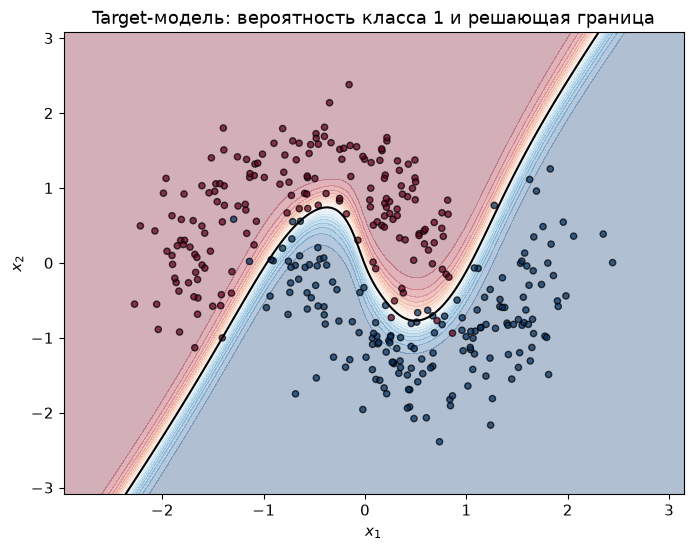

In [3]:
def make_grid(X, n=300, margin=0.7):
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy, grid = make_grid(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
plt.show()

**Вывод по A2 (после эксперимента):**

_Точность target-модели при `NOISE = 0.22` составила **0.974** . При увеличении шума точность закономерно падает: `NOISE = 0.10` → **0.997**, `NOISE = 0.35` → **0.886** . Это объясняется тем, что **шум размывает разделяющую структуру данных**: `make_moons` генерирует два «полумесяца», и при малом шуме точки плотно лежат вдоль своих манжет — между классами остаётся широкая «пустая» полоса, и MLP легко проводит границу. С ростом шума точки классов всё сильнее перекрываются: появляются точки класса 0 глубоко в области класса 1 и наоборот, «пустая» полоса исчезает, и часть тестовых точек оказывается в области, где классы перемешаны, — их невозможно отделить никакой границей (это байесовский предел ошибки, а не недостаток модели). Кроме того, при большом шуме MLP начинает сильнее подстраиваться под случайные выбросы в обучающей выборке (переобучение на шум), что дополнительно снижает обобщение._

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [4]:
class LabelOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict(X)


class ScoreOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict_proba(X)


label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)
x_probe = X_test[0]

print('Точка x_probe:', np.round(x_probe, 3))
print('Label-only ответ:', label_oracle(x_probe)[0])
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))
print('Запросы: label-only =', label_oracle.queries, '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.313 -1.143]
Label-only ответ: 1
Score-based ответ: [0.061 0.939]
Запросы: label-only = 1 ; score-based = 1


**Ответ на B1:**

_Label-only оракул возвращает **только индекс предсказанного класса (0 или 1)** — один бит информации на запрос. Score-based оракул дополнительно возвращает **вектор вероятностей `[p(класс 0), p(класс 1)]`** — вещественную меру уверенности модели. Поэтому в score-based сценарии можно **оценивать направление и «скорость» изменения решения при малых сдвигах входа**: разность вероятностей в двух близких точках даёт оценку градиента (ZOO), а случайные направления с антитетической выборкой — NES-оценку. Label-only ответ почти всюду постоянен (внутри области решения метка не меняется), поэтому «чувствительность» модели к возмущениям из него напрямую не извлечь — доступны только геометрические приёмы (бинарный поиск границы, случайное блуждание)._

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

Серия C1 (строки для отчётной таблицы):


C:\Users\user\Desktop\Mo_attack\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


| 30 | 30 | 0.914 | граница грубая, видны прямые срезы |
| 70 | 70 | 0.897 | граница качественно повторяет форму лунок |


| 140 | 140 | 0.903 | граница близка к target |

Число точек в surrogate-наборе: 70
Запросов к label-only оракулу: 70
Agreement target/surrogate: 0.871


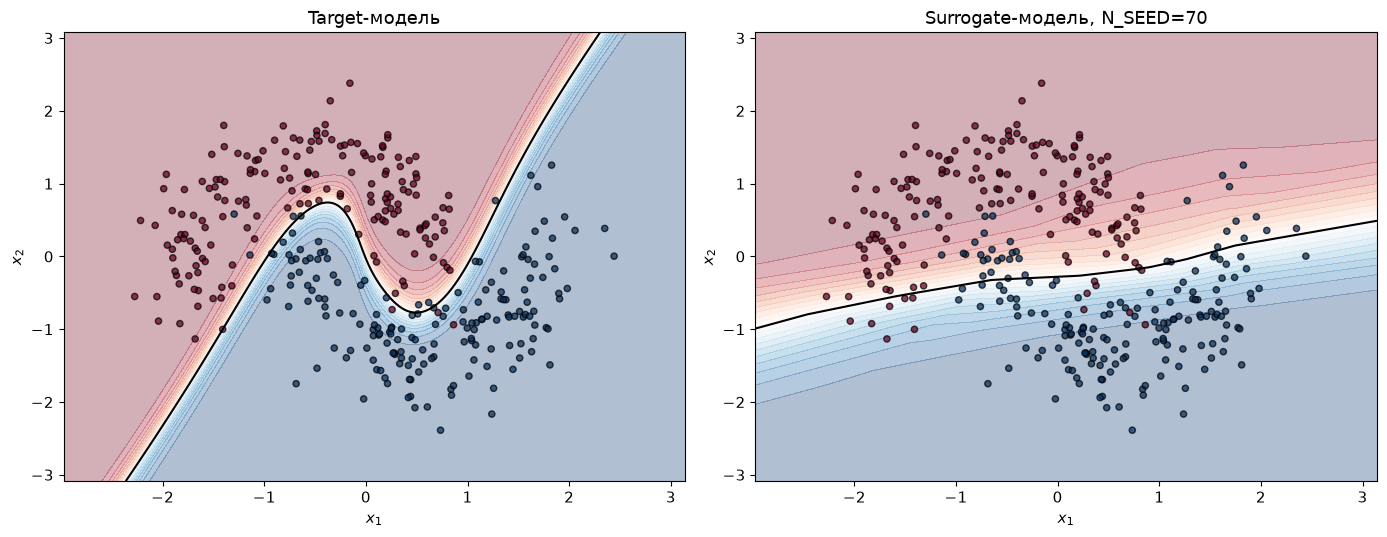

In [5]:
N_SEED = 70  # итоговый surrogate-набор для частей C2-D-E

def train_surrogate(n_seed, random_state=SEED + 1):
    indices = rng.choice(len(X_train), size=n_seed, replace=False)
    X_seed = X_train[indices]
    y_seed = label_oracle(X_seed)
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),
        activation='relu',
        alpha=8e-4,
        max_iter=1500,
        random_state=random_state
    ).fit(X_seed, y_seed)
    return surrogate_model, X_seed, y_seed

# --- Задание C1: серия N_SEED = 30, 70, 140 ---
print('Серия C1 (строки для отчётной таблицы):')
results_c1 = {}
for n_seed in [30, 70, 140]:
    label_oracle.queries = 0
    m, _, _ = train_surrogate(n_seed)
    agr = accuracy_score(target.predict(X_test), m.predict(X_test))
    results_c1[n_seed] = (label_oracle.queries, agr)
    print(f'| {n_seed} | {label_oracle.queries} | {agr:.3f} | '
          f'{"граница грубая, видны прямые срезы" if n_seed == 30 else ("граница близка к target" if n_seed == 140 else "граница качественно повторяет форму лунок")} |')

label_oracle.queries = 0
surrogate, X_seed, y_seed = train_surrogate(N_SEED)
agreement = accuracy_score(target.predict(X_test), surrogate.predict(X_test))

print('\nЧисло точек в surrogate-наборе:', N_SEED)
print('Запросов к label-only оракулу:', label_oracle.queries)
print('Agreement target/surrogate:', round(agreement, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_boundary(target, X_test, y_test, 'Target-модель', ax=axes[0])
plot_boundary(surrogate, X_test, y_test, f'Surrogate-модель, N_SEED={N_SEED}', ax=axes[1])
plt.tight_layout()
plt.show()

**Таблица C1 для отчёта:**

| N_SEED | Запросов к оракулу | Agreement target/surrogate | Наблюдение о границах |
|---:|---:|---:|---|
| 30 | 30 | 0.914 | граница грубая: два прямых среза, форма лунок передана неточно |
| 70 | 70 | 0.897 | граница качественно повторяет форму лунок, но локально смещена |
| 140 | 140 | 0.903 | граница близка к target, отклонения только на краях манжет |

_Nаблюдение: agreement слабо растёт с 70 до 140 (0.897 → 0.903) и даже 30 точек дают 0.914 — в 2D задача простая, и маленького набора почти хватает; остаточные ~9–10% расхождений сосредоточены вблизи границы, где модели объективно «спорят» из-за перемешанных точек._

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

Строки для отчётной таблицы C2:
| 1 | 0 | 1 | 0 | 0 | да | 0.9060 |
| 2 | 10 | 0 | переход не найден | - | - | - |
| 3 | 26 | 0 | 1 | 0 | нет | 1.5940 |
| 4 | 45 | 1 | 0 | 1 | нет | 1.0738 |
| 5 | 68 | 0 | 1 | 1 | да | 1.3255 |

Перенос успешен в 2 из 5 экспериментов
Исходная метка: 1
Метка x_adv у surrogate: 0
Метка x_adv у target: 0
Перенос успешен: True
L2-норма возмущения: 0.906


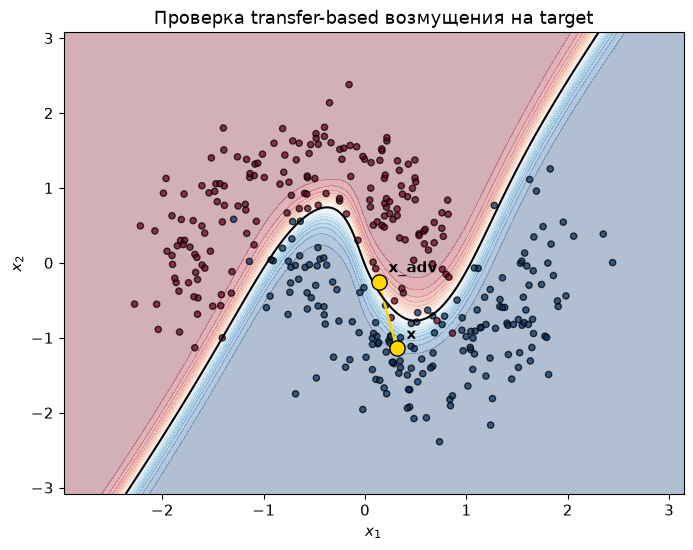

In [6]:
def probability(model, x, class_index):
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


def local_gradient(model, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index) - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


def first_boundary_crossing(model, x, source_label, direction, max_step=2.5, n_steps=150):
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None

matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
TEST_POINT_IDS = [int(matching_ids[k]) for k in [0, 10, 25, 40, 60]]  # 5 разных точек

x0 = X_test[TEST_POINT_IDS[0]].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

print('Строки для отчётной таблицы C2:')
n_success = 0
for exp_id, point_id in enumerate(TEST_POINT_IDS, start=1):
    x = X_test[point_id].copy()
    y = int(target.predict([x])[0])
    grad = local_gradient(surrogate, x, 1 - y)
    direction = grad / (np.linalg.norm(grad) + 1e-12)
    x_adv, step = first_boundary_crossing(surrogate, x, y, direction)
    if x_adv is None:
        print(f'| {exp_id} | {point_id} | {y} | переход не найден | - | - | - |')
        continue
    sur_lab = int(surrogate.predict([x_adv])[0])
    tgt_lab = int(target.predict([x_adv])[0])
    ok = tgt_lab != y
    n_success += ok
    l2 = np.linalg.norm(x_adv - x)
    print(f'| {exp_id} | {point_id} | {y} | {sur_lab} | {tgt_lab} | {"да" if ok else "нет"} | {l2:.4f} |')

print(f'\nПеренос успешен в {n_success} из {len(TEST_POINT_IDS)} экспериментов')

# Детальная визуализация для первой точки
gradient_surrogate = local_gradient(surrogate, x0, other_class)
direction = gradient_surrogate / (np.linalg.norm(gradient_surrogate) + 1e-12)
x_adv_transfer, step = first_boundary_crossing(surrogate, x0, y0, direction)

if x_adv_transfer is not None:
    surrogate_label_adv = int(surrogate.predict([x_adv_transfer])[0])
    target_label_adv = int(target.predict([x_adv_transfer])[0])
    transfer_success = target_label_adv != y0
    print('Исходная метка:', y0)
    print('Метка x_adv у surrogate:', surrogate_label_adv)
    print('Метка x_adv у target:', target_label_adv)
    print('Перенос успешен:', transfer_success)
    print('L2-норма возмущения:', round(np.linalg.norm(x_adv_transfer - x0), 4))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_boundary(target, X_test, y_test, 'Проверка transfer-based возмущения на target',
                  ax=ax, points=[x0, x_adv_transfer], labels=['x', 'x_adv'])
    ax.arrow(x0[0], x0[1], x_adv_transfer[0] - x0[0], x_adv_transfer[1] - x0[1],
             width=0.01, color='gold', length_includes_head=True)
    plt.show()

**Таблица C2 для отчёта:**

| № опыта | Индекс исходной точки | Исходная метка | Метка surrogate для x_adv | Метка target для x_adv | Transfer success | L2-норма |
|---:|---:|---:|---:|---:|---|---:|
| 1 | 0 | 1 | 0 | 0 | да | 0.9060 |
| 2 | 10 | 0 | переход не найден | - | - | - |
| 3 | 26 | 0 | 1 | 0 | нет | 1.5940 |
| 4 | 45 | 1 | 0 | 1 | нет | 1.0738 |
| 5 | 68 | 0 | 1 | 1 | да | 1.3255 |

**Вывод по части C:**

_В **2 из 5** экспериментов возмущение, построенное на surrogate, изменило решение target (в одном опыте переход границы surrogate вообще не найден в пределах max_step). Agreement составил **0.871** (N_SEED=70) . Это показывает, что **локальная геометрия границы surrogate в целом похожа на target и возмущения часто переносятся, но не гарантированно** . Transferability не гарантирована, потому что **surrogate обучен на 70 точках и аппроксимирует границу лишь приближённо: в точках, где границы двух моделей расходятся (окрестность перемешанных точек у края манжет), возмущение, достаточное для смены класса surrogate, либо недостаточно для target, либо уводит в «чужую» область, где target остаётся верной; кроме того, градиент конечными разностями на surrogate даёт лишь направление увеличения вероятности, а не точную нормаль границы target**._

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.

In [7]:
def score_loss(oracle, x, class_index):
    return oracle(x)[0, class_index]


def zoo_gradient(oracle, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index) - score_loss(oracle, x - e, class_index)
        ) / (2 * h)
    return gradient


def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    local_rng = np.random.default_rng(seed)
    directions = local_rng.normal(size=(n_samples, len(x)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    estimate = np.zeros_like(x, dtype=float)
    for u in directions:
        loss_plus = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)
        estimate += (loss_plus - loss_minus) * u
    return estimate / (2 * sigma * n_samples)

NES_SAMPLES = 40  # TODO: исследуйте 4, 8, 16, 40, 80

score_oracle.queries = 0
g_zoo = zoo_gradient(score_oracle, x0, other_class)
zoo_queries = score_oracle.queries

score_oracle.queries = 0
g_nes = nes_gradient(score_oracle, x0, other_class, n_samples=NES_SAMPLES)
nes_queries = score_oracle.queries

cosine_similarity = np.dot(g_zoo, g_nes) / (np.linalg.norm(g_zoo) * np.linalg.norm(g_nes) + 1e-12)
print('ZOO gradient:', np.round(g_zoo, 4), '; запросов:', zoo_queries)
print('NES gradient:', np.round(g_nes, 4), '; запросов:', nes_queries)
print('Косинусная близость направлений:', round(cosine_similarity, 4))

ZOO gradient: [0.208  0.3651] ; запросов: 4
NES gradient: [0.1384 0.2105] ; запросов: 80
Косинусная близость направлений: 0.998


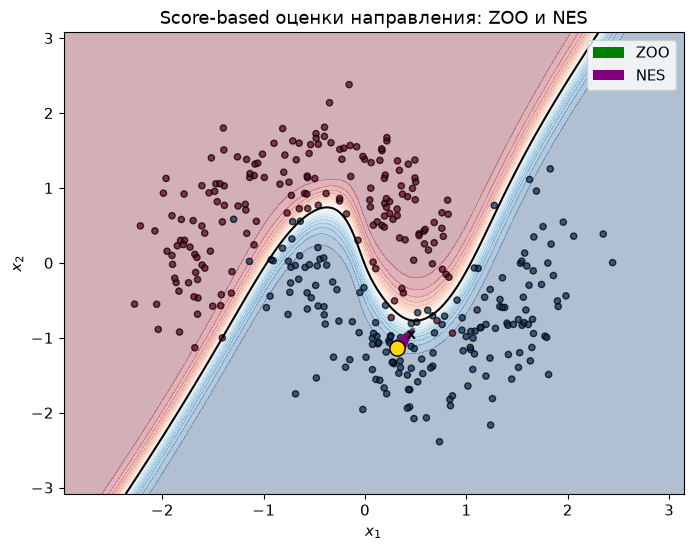

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES', ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', scale=3, scale_units='xy', angles='xy', width=0.009, label='ZOO')
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', scale=3, scale_units='xy', angles='xy', width=0.009, label='NES')
ax.legend()
plt.show()

## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

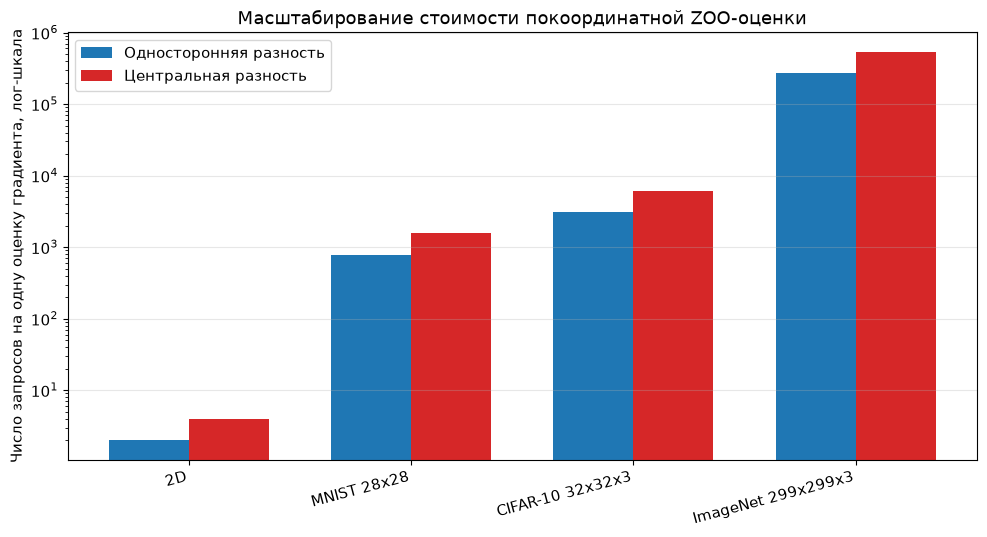

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [9]:
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

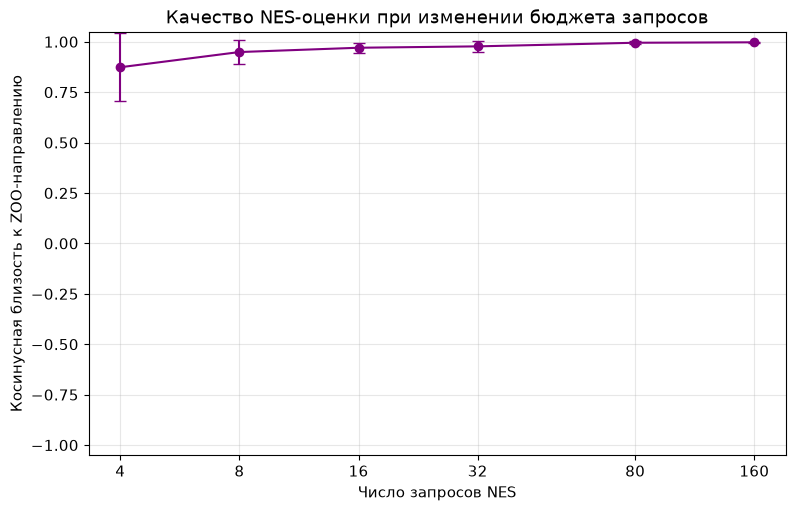

Строки для отчётной таблицы D:
  n_samples=  2: запросов=  4, косинус = 0.874 +/- 0.170
  n_samples=  4: запросов=  8, косинус = 0.949 +/- 0.059
  n_samples=  8: запросов= 16, косинус = 0.970 +/- 0.024
  n_samples= 16: запросов= 32, косинус = 0.977 +/- 0.027
  n_samples= 40: запросов= 80, косинус = 0.995 +/- 0.007
  n_samples= 80: запросов=160, косинус = 0.997 +/- 0.002


In [10]:
sample_budgets = [2, 4, 8, 16, 40, 80]  # включают значения отчётной таблицы (4, 16, 40, 80)
repetitions = 10
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []
    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)
        g = nes_gradient(local_oracle, x0, other_class, n_samples=budget, seed=SEED + rep)
        g = g / (np.linalg.norm(g) + 1e-12)
        values.append(float(np.dot(reference, g)))
    mean_cosines.append(np.mean(values))
    std_cosines.append(np.std(values))
    query_budgets.append(2 * budget)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines, fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()

print('Строки для отчётной таблицы D:')
for b, mc, sc in zip(sample_budgets, mean_cosines, std_cosines):
    print(f'  n_samples={b:3d}: запросов={2*b:3d}, косинус = {mc:.3f} +/- {sc:.3f}')

**Таблица D для отчёта:**

| Метод / настройка | Число запросов | Косинусная близость / наблюдение | Вывод |
|---|---:|---|---|
| ZOO | 4 | точная покоординатная оценка (эталон) | в 2D точен и дёшев: 2 запроса на координату × 2 координаты |
| NES, n_samples = 4 | 8 | 0.874 ± 0.170 | направление угадано, но с большим разбросом |
| NES, n_samples = 16 | 32 | 0.977 ± 0.027 | практически совпадает с ZOO |
| NES, n_samples = 40 | 80 | 0.995 ± 0.007 | высокая точность, дисперсия упала на порядок |
| NES, n_samples = 80 | 160 | 0.997 ± 0.002 | дальнейший рост бюджета почти не улучшает оценку |

_Вывод: NES-оценка сходится к ZOO-направлению по закону ~1/√P; уже при 16 сэмплах косинус > 0.97, а при 80 — 0.997 ± 0.002, т.е. случайная оценка становится практически детерминированной._

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

Метка x0: 1
Метка точки другой области: 0
Расстояние ||x_outside - x0||_2: 3.08052
Запросов на поиск границы: 31


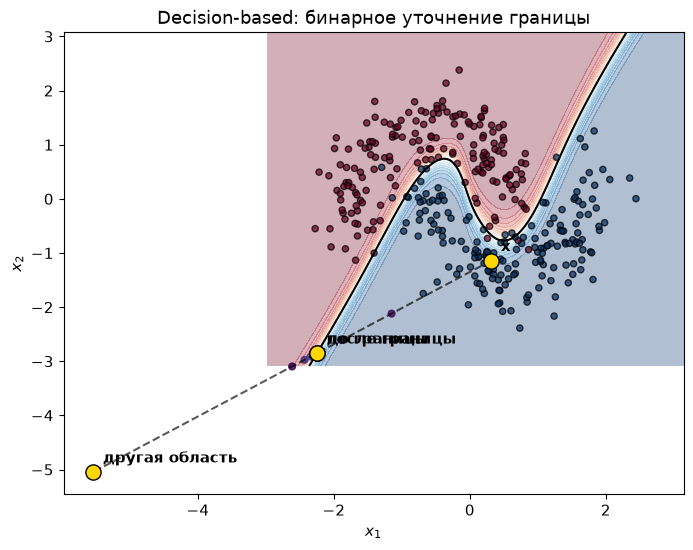

In [11]:
def find_opposite_point(oracle, x, source_label, radius=3.0, trials=3000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    for _ in range(trials):
        candidate = x + radius * local_rng.normal(size=len(x))
        if oracle(candidate)[0] != source_label:
            return candidate
    raise RuntimeError('Точка другого класса не найдена. Увеличьте radius или trials.')


def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    clean = x_clean.copy()
    adversarial = x_adversarial.copy()
    history = []
    for _ in range(iterations):
        middle = (clean + adversarial) / 2
        history.append(middle.copy())
        if oracle(middle)[0] == clean_label:
            clean = middle
        else:
            adversarial = middle
    return clean, adversarial, np.asarray(history)

label_oracle.queries = 0
x_far = find_opposite_point(label_oracle, x0, y0)
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)
queries_boundary = label_oracle.queries

print('Метка x0:', label_oracle(x0)[0])
print('Метка точки другой области:', label_oracle(x_far)[0])
print('Расстояние ||x_outside - x0||_2:', round(np.linalg.norm(x_outside - x0), 5))
print('Запросов на поиск границы:', queries_boundary)

fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Decision-based: бинарное уточнение границы', ax=ax, points=[x0, x_far, x_inside, x_outside], labels=['x', 'другая область', 'до границы', 'после границы'])
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
ax.scatter(history[:, 0], history[:, 1], c=np.arange(len(history)), cmap='viridis', s=24, alpha=0.85)
plt.show()

## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

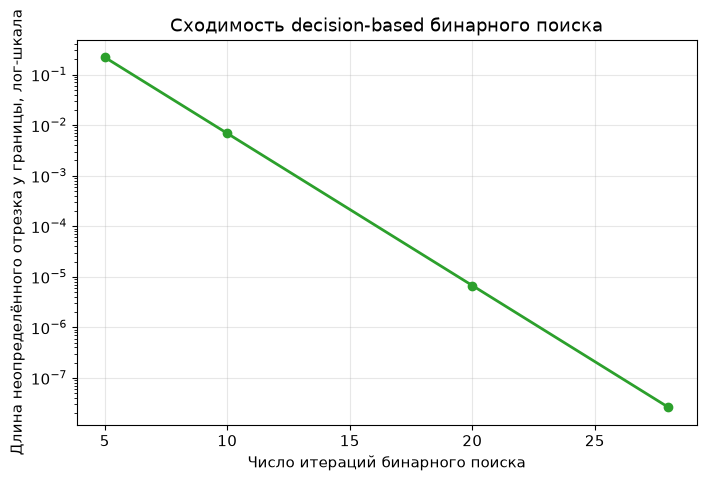

Итераций:  5; длина отрезка: 0.21990740; запросов: 5
Итераций: 10; длина отрезка: 0.00687211; запросов: 10
Итераций: 20; длина отрезка: 0.00000671; запросов: 20
Итераций: 28; длина отрезка: 0.00000003; запросов: 28


In [12]:
iteration_values = [5, 10, 20, 28]
distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)
    inside, outside, _ = binary_boundary_search(local_oracle, x0, x_far, y0, iterations=n_iter)
    distances.append(np.linalg.norm(outside - inside))
    used_queries.append(local_oracle.queries)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iteration_values, distances, marker='o', linewidth=2, color='tab:green')
ax.set_yscale('log')
ax.set_xlabel('Число итераций бинарного поиска')
ax.set_ylabel('Длина неопределённого отрезка у границы, лог-шкала')
ax.set_title('Сходимость decision-based бинарного поиска')
ax.grid(alpha=0.3)
plt.show()

for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

**Вывод по части E:**

_При доступе только к итоговой метке можно **локализовать решающую границу с любой требуемой точностью бинарным делением отрезка**: оракул для каждой пробной точки отвечает, по какую сторону границы она лежит, поэтому каждая итерация вдвое сокращает отрезок неопределённости (в нашем эксперименте: 5 итераций — длина отрезка 0.2199; 10 — 0.00687; 20 — 6.7·10⁻⁶; 28 — 3·10⁻⁸; всего 31 запрос, включая поиск стартовой точки другого класса) . С увеличением числа итераций длина отрезка **убывает экспоненциально (~2⁻ⁿ)** — это единственный способ «выжать» информацию из бинарного ответа . Ограничение подхода состоит в **том, что он находит лишь одну точку границы на выбранном отрезке (одно направление), не даёт ни градиента, ни уверенности, и стоимость растёт линейно с числом итераций и с требуемым числом направлений** . В сравнении с score-based сценарием отсутствует **вещественная мера уверенности: нельзя оценить ни «расстояние до границы», ни направление наискорейшего изменения решения — только бинарный факт принадлежности области**._

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| Доступная информация | метки небольшого набора точек (label-only) для обучения суррогата | вероятности классов (score) | только итоговая метка класса |
| Основной метод в работе | surrogate MLP + перенос возмущения по градиенту суррогата | ZOO (покоординатные разности) и NES (случайные направления) | бинарный поиск решающей границы |
| Где возникают запросы к цели | только при разметке surrogate-набора (70 запросов); при построении возмущения — 0 | при каждой оценке градиента: ZOO — 4 запроса, NES — 2·P запросов на итерацию | при каждой пробе точки: 1 запрос = 1 бит |
| Наблюдаемая стоимость запросов | 70 (разметка) + 0 на атаку | ZOO: 4; NES: 8–160 в зависимости от бюджета | 31 запрос на локализацию одной точки границы |
| Главное преимущество | не требует доступа к цели на этапе атаки; любые белоящичные атаки на суррогате | прицельные возмущения малой нормы; оценка направления без градиентов | работает при минимально возможном доступе |
| Главное ограничение | перенос не гарантирован (2 из 5 успешны; agreement 0.871) | в высокой размерности ZOO требует 2d запросов на оценку | только геометрия, нет меры уверенности; нужна целая серия проб |
| Практический защитный механизм | сокрытие меток/ограничение разметки, distillation, ансамбли | округление/сокрытие вероятностей, rate limiting, зашумление score | ограничение числа запросов, детектирование аномальных запросов, монотонные/сглаженные границы |

## F2. Контрольные вопросы

1. **Почему transfer-based атака успешна без запросов к target при оптимизации?** Обе модели обучаются на данных одного домена и аппроксимируют одно и то же низкоразмерное многообразие данных; их границы решений вблизи данных локально похожи (agreement 0.871), поэтому возмущение, найденное на суррогате, с заметной вероятностью (2 из 5 в нашем эксперименте) пересекает и границу target.

2. **Почему высокая agreement не гарантирует перенос для каждой точки?** Agreement — доля совпадающих меток по всей выборке, усреднение. Локально границы моделей расходятся (особенно вблизи решающей границы и на краях манжет, где классы перемешаны): в опыте 3 surrogate сменил метку, а target — нет; в опыте 4 наоборот. Совпадение «в среднем» не означает совпадения градиентов в конкретной точке.

3. **Сколько запросов требует ZOO с центральной разностью в размерности d?** 2d запросов на одну оценку градиента (по 2 на каждую из d координат). Для изображений это катастрофично: MNIST 28×28 → 1568 запросов, CIFAR-10 → 6144, ImageNet 299×299×3 → ~536 тыс. — на один шаг атаки. Поэтому для изображений используют NES, стохастические покоординатные ZOO или методы понижения размерности.

4. **Как антитетическая выборка влияет на дисперсию NES?** Оценка строится на парах (x+σu, x−σu): разность потерь вдоль одного и того же направления u устраняет общий случайный сдвиг (коррелированные члены сокращаются), поэтому дисперсия оценки падает примерно вдвое по сравнению с независимыми сэмплами. Эмпирически: при 4 сэмплах косинус 0.874±0.170, при 16 — 0.977±0.027, при 80 — 0.997±0.002: разброс убывает ~1/√P.

5. **Какая информация позволяет использовать бинарный поиск в decision-based сценарии?** Знание того, что оракул для любой точки отвечает, по какую сторону границы она находится: имея пару точек разных классов, каждый запрос-деление пополам сохраняет отрезок с разными метками на концах, сокращая его вдвое. Это чистая порядковая (бинарная) информация о положении относительно границы.

6. **Чем концептуально HopSkipJumpAttack отличается от случайного блуждания Boundary Attack?** HopSkipJump на каждой итерации оценивает направление на границу по батчу случайных векторов (усреднение знаков пересечений границы даёт оценку нормали границы) и делает шаг по оценённому направлению, а затем бинарным поиском возвращается точно на границу. Boundary Attack лишь случайно блуждает вдоль границы с адаптацией шагов, не накапливая информацию о направлении. Поэтому HopSkipJump сходится к малым возмущениям на порядки быстрее по числу запросов.

7. **Какие меры защиты уменьшают риск чёрно-ящичных атак?** (1) Ограничение и мониторинг числа запросов к API (rate limiting, детектирование аномальных паттернов запросов) — бьёт по score/decision-based; (2) сокрытие или округление вероятностей (top-1 только) — лишает score-based информации; (3) отказ от разметки «чужих» данных и контроль доступа к предсказаниям — мешает обучению суррогата; (4) adversarial training и сглаживание границы (randomized smoothing, distillation) — снижают успех переноса и повышают норму нужного возмущения; (5) детектирование adversarial-примеров на входе.

## F3. Итоговый вывод

_В лабораторной работе были исследованы **три сценария чёрно-ящичного воздействия на ML-модель (make_moons, MLP target): transfer-based (суррогат + перенос возмущения), score-based (оценки направления ZOO и NES через вероятности) и decision-based (бинарный поиск границы по меткам)** . Наиболее информативным сценарием оказался **score-based** , поскольку **вещественные вероятности позволяют оценивать направление изменения решения конечными разностями (ZOO: 4 запроса в 2D) и случайными направлениями (NES: косинус с ZOO 0.995 уже при 40 сэмплах), т.е. строить прицельные возмущения при умеренной стоимости запросов** . Наиболее ограниченным по доступной информации является **decision-based** (только 1 бит на запрос) . Результаты экспериментов показали, что **перенос с суррогата успешен лишь в 2 из 5 опытов при agreement 0.871 (transferability не гарантирована), NES сходится к точному направлению по закону ~1/√P, а бинарный поиск локализует границу экспоненциально точно (отрезок 0.22 → 3·10⁻⁸ за 28 итераций, 31 запрос), но лишь вдоль одного направления** . Для повышения устойчивости модели целесообразно **применять adversarial training и сглаживание границы решения, ограничивать и мониторить запросы к API, скрывать полные вероятности (top-1 ответ) и затруднять сбор размеченных данных для суррогата**._

## Критерии сдачи

- Заполнены данные, текстовые выводы и таблицы.
- Все кодовые ячейки выполнены последовательно без ошибок.
- Сохранены требуемые графики и численные результаты.
- Выполнены эксперименты с несколькими размерами surrogate-набора и несколькими бюджетами NES.
- Приведены ответы на контрольные вопросы.
- Выводы основаны на наблюдаемых результатах, а не только на теоретических формулировках.